In [ ]:
!pip install pandas numpy matplotlib

In [1]:
path = "../data/affect+frame+choice+test_2026年8月24日_21.18.csv" #適宜変更

In [2]:
import pandas as pd
data = pd.read_csv(path, header=0)

/tmp/ipykernel_538217/2728496023.py:2: DtypeWarning: Columns (0: Progress, 1: Duration (in seconds), 2: Finished, 3: RecipientLastName, 4: RecipientFirstName, 5: RecipientEmail, 6: ExternalReference, 7: LocationLatitude, 8: LocationLongitude, 9: 最後に表示された質問ID, 10: D2_1, 11: 1_Q3_First Click, 12: 1_Q3_Last Click, 13: 1_Q3_Page Submit, 14: 1_Q3_Click Count, 15: 1_Q4_1, 16: 1_Q5_1, 17: 2_Q3_First Click, 18: 2_Q3_Last Click, 19: 2_Q3_Page Submit, 20: 2_Q3_Click Count, 21: 2_Q4_1, 22: 2_Q5_1, 23: 3_Q3_First Click, 24: 3_Q3_Last Click, 25: 3_Q3_Page Submit, 26: 3_Q3_Click Count, 27: 3_Q4_1, 28: 3_Q5_1, 29: 4_Q3_First Click, 30: 4_Q3_Last Click, 31: 4_Q3_Page Submit, 32: 4_Q3_Click Count, 33: 4_Q4_1, 34: 4_Q5_1, 35: 5_Q3_First Click, 36: 5_Q3_Last Click, 37: 5_Q3_Page Submit, 38: 5_Q3_Click Count, 39: 5_Q4_1, 40: 5_Q5_1, 41: F3_First Click, 42: F3_Last Click, 43: F3_Page Submit, 44: F3_Click Count, 45: 1_Q8_First Click, 46: 1_Q8_Last Click, 47: 1_Q8_Page Submit, 48: 1_Q8_Click Count, 49: 1_Q9_

In [3]:
# 1行目をベクトルとして保存
questions = data.iloc[0].copy()

# 2行目を除外し、3行目以降をDataFrameとして保存
df = data.iloc[2:].copy()

In [4]:
print(questions.head())
print(questions.shape)

StartDate       開始日
EndDate         終了日
Status        回答タイプ
IPAddress    IPアドレス
Progress       進行状況
Name: 0, dtype: object
(5232,)


#### ip重複消去

In [5]:
ip_data = df["IPAddress"]

In [6]:
ip_data

2      106.131.113.204
3          1.73.18.151
4        126.72.104.33
5      219.104.142.133
6      123.225.222.135
            ...       
203     114.161.255.58
204       60.88.94.155
205    210.139.197.228
206      61.86.247.145
207     157.112.163.70
Name: IPAddress, Length: 206, dtype: str

In [7]:
#重複IPの検知

ip_counts = df["IPAddress"].value_counts()

print(ip_counts[ip_counts > 1])

IPAddress
1.73.18.151       2
120.75.106.148    2
38.77.153.227     2
133.32.183.250    2
119.228.10.155    2
49.97.23.85       2
202.78.182.29     2
Name: count, dtype: int64


In [8]:
duplication_data = df[df["IPAddress"].duplicated(keep=False)].sort_values("IPAddress")

print(duplication_data)

#特定IP（重複）の削除
delete_ips = ["119.228.10.155", "120.75.106.148", "133.32.183.250", "202.78.182.29", "38.77.153.227", "49.97.23.85"]

#DFの更新
df = df[~df["IPAddress"].isin(delete_ips)]

#重複の内,最後の分を保持する（スマホ回答 -> PC回答）　特定IP削除後の処理　順番関係あり
df = df.drop_duplicates(subset="IPAddress", keep="last")

#スマホ回答のみの回答者 削除
df = df.dropna(subset=["D1"])

               StartDate              EndDate      Status       IPAddress  \
3    2026-08-22 09:38:33  2026-08-22 09:38:37  IP Address     1.73.18.151   
8    2026-08-22 09:39:07  2026-08-22 09:53:53  IP Address     1.73.18.151   
106  2026-08-22 09:37:20  2026-08-22 10:23:13  IP Address  119.228.10.155   
172  2026-08-22 10:25:10  2026-08-22 11:05:19  IP Address  119.228.10.155   
28   2026-08-22 09:48:43  2026-08-22 10:03:27  IP Address  120.75.106.148   
176  2026-08-22 10:49:36  2026-08-22 11:12:07  IP Address  120.75.106.148   
77   2026-08-22 09:40:35  2026-08-22 10:12:10  IP Address  133.32.183.250   
165  2026-08-22 10:13:57  2026-08-22 10:52:12  IP Address  133.32.183.250   
161  2026-08-22 09:33:50  2026-08-22 10:50:46  IP Address   202.78.182.29   
169  2026-08-22 09:41:24  2026-08-22 11:00:38  IP Address   202.78.182.29   
33   2026-08-22 09:43:35  2026-08-22 10:03:53  IP Address   38.77.153.227   
120  2026-08-22 10:04:02  2026-08-22 10:27:13  IP Address   38.77.153.227   

In [ ]:
df

#### continuous_value_detectionの前処理介入

#### 実験１
- Alertness Level
対象者数
2
対象者ID
Index(['R_9RIigVF3ZQo8dot', 'R_9fjg4QiR4XFQwmu'], dtype='str', name='responseId')

#### 実験２

- Affect Level　対象者数5　対象者ID　['R_4EvdHoKC5DPcEFa', 'R_4s5g2hV3Ym94UgH', 'R_4whpRXq41xrMpDm',
       'R_9scu1S8qhZLB7JT', 'R_9tkj3qpo41rhRrX'],
- Alertness Level 対象者数5 対象者ID ['R_4M2nNbp82pIAmOJ', 'R_4s5g2hV3Ym94UgH', 'R_9TMmpGaAsS8pxzB',
       'R_9scu1S8qhZLB7JT', 'R_9yDb9mGzgFuZLPP']

In [9]:
delete_ResponceId = ['R_406piivDmShdVkR',
                     'R_98CCmrZLuPem2Z1',
                     'R_9OwRUAA1BoKmvhl',
                     'R_9d3P33wTPvC95vK',
                     'R_9dukvbnZkwMhA8D',
                     
                     'R_9RIigVF3ZQo8dot',
                     'R_9fjg4QiR4XFQwmu',
                     
                     'R_4EvdHoKC5DPcEFa', 
                     'R_4s5g2hV3Ym94UgH', 
                     'R_4whpRXq41xrMpDm',
                     'R_9scu1S8qhZLB7JT',
                     'R_9tkj3qpo41rhRrX',
                     
                     'R_4M2nNbp82pIAmOJ',
                     'R_4s5g2hV3Ym94UgH',
                     'R_9TMmpGaAsS8pxzB',
                     'R_9scu1S8qhZLB7JT',
                     'R_9yDb9mGzgFuZLPP'
                     ]

df = df[~df["ResponseId"].isin(delete_ResponceId)]


In [10]:
#191 5232 -> 191 5233
df.shape

(176, 5232)

In [11]:
columns = df.columns.tolist()
print(columns)

['StartDate', 'EndDate', 'Status', 'IPAddress', 'Progress', 'Duration (in seconds)', 'Finished', 'RecordedDate', 'ResponseId', 'RecipientLastName', 'RecipientFirstName', 'RecipientEmail', 'ExternalReference', 'LocationLatitude', 'LocationLongitude', 'DistributionChannel', 'UserLanguage', '最後に表示されたフロー要素ID', '最後に表示された質問ID', 'D1', 'D2_1', '1_Q3_First Click', '1_Q3_Last Click', '1_Q3_Page Submit', '1_Q3_Click Count', '1_Q4_1', '1_Q5_1', '2_Q3_First Click', '2_Q3_Last Click', '2_Q3_Page Submit', '2_Q3_Click Count', '2_Q4_1', '2_Q5_1', '3_Q3_First Click', '3_Q3_Last Click', '3_Q3_Page Submit', '3_Q3_Click Count', '3_Q4_1', '3_Q5_1', '4_Q3_First Click', '4_Q3_Last Click', '4_Q3_Page Submit', '4_Q3_Click Count', '4_Q4_1', '4_Q5_1', '5_Q3_First Click', '5_Q3_Last Click', '5_Q3_Page Submit', '5_Q3_Click Count', '5_Q4_1', '5_Q5_1', 'F3_First Click', 'F3_Last Click', 'F3_Page Submit', 'F3_Click Count', 'F4', '1_Q8_First Click', '1_Q8_Last Click', '1_Q8_Page Submit', '1_Q8_Click Count', '1_Q9_1', '

#### 参加者データのグラフ化等

In [12]:
# separate experiment 1 and 2
target = "コップの中には何ml程度水が入っていますか"

mask = data.iloc[0].astype(str).str.contains(target, na=False)

matches = [
    (i, data.columns[i])
    for i in range(len(data.columns))
    if mask.iloc[i]
]

print(matches)
print(len(matches))



[(1930, '1_Q2_1'), (1941, '2_Q2_1'), (1952, '3_Q2_1'), (1963, '4_Q2_1'), (1974, '5_Q2_1'), (1985, '1_Q741_1'), (1996, '2_Q741_1'), (2007, '3_Q741_1'), (2018, '4_Q741_1'), (2029, '5_Q741_1'), (2040, '1_Q748_1'), (2051, '2_Q748_1'), (2062, '3_Q748_1'), (2073, '4_Q748_1'), (2084, '5_Q748_1'), (2095, '1_Q755_1'), (2106, '2_Q755_1'), (2117, '3_Q755_1'), (2128, '4_Q755_1'), (2139, '5_Q755_1'), (2150, '1_Q762_1'), (2161, '2_Q762_1'), (2172, '3_Q762_1'), (2183, '4_Q762_1'), (2194, '5_Q762_1'), (2205, '1_Q769_1'), (2216, '2_Q769_1'), (2227, '3_Q769_1'), (2238, '4_Q769_1'), (2249, '5_Q769_1'), (2260, '1_Q776_1'), (2271, '2_Q776_1'), (2282, '3_Q776_1'), (2293, '4_Q776_1'), (2304, '5_Q776_1'), (2315, '1_Q783_1'), (2326, '2_Q783_1'), (2337, '3_Q783_1'), (2348, '4_Q783_1'), (2359, '5_Q783_1'), (2370, '1_Q790_1'), (2381, '2_Q790_1'), (2392, '3_Q790_1'), (2403, '4_Q790_1'), (2414, '5_Q790_1'), (2425, '1_Q797_1'), (2436, '2_Q797_1'), (2447, '3_Q797_1'), (2458, '4_Q797_1'), (2469, '5_Q797_1'), (2480, '1

In [13]:
target = "コップの中には何ml程度水が入っていますか"

mask = questions.astype(str).str.contains(target, na=False)

target_columns = questions.index[mask]

is_exp1 = df[target_columns].isna().all(axis=1)

exp1 = df[is_exp1]
exp2 = df[~is_exp1]

print("対象列数:", len(target_columns))
print("全参加者:", len(df))
print("実験1:", len(exp1))
print("実験2:", len(exp2))
print("合計:", len(exp1) + len(exp2))

対象列数: 300
全参加者: 176
実験1: 88
実験2: 88
合計: 176


In [14]:
#exp1 と exp2　のDFを作成した
print(is_exp1.value_counts())

True     88
False    88
Name: count, dtype: int64


In [15]:
# group
print("whole :\n")
print(df["__js_MessageGroup"].value_counts(dropna=False))

print("\nexp1 :\n")
print(exp1["__js_MessageGroup"].value_counts(dropna=False))
print("\nexp2 :\n")
print(exp2["__js_MessageGroup"].value_counts(dropna=False))

whole :

__js_MessageGroup
neutral     62
positive    59
negative    55
Name: count, dtype: int64

exp1 :

__js_MessageGroup
neutral     30
negative    30
positive    28
Name: count, dtype: int64

exp2 :

__js_MessageGroup
neutral     32
positive    31
negative    25
Name: count, dtype: int64


In [16]:
# demographic
print("whole :\n")
print(df["D1"].value_counts(dropna=False))

print("\nexp1 :\n")
print(exp1["D1"].value_counts(dropna=False))
print("\nexp2 :\n")
print(exp2["D1"].value_counts(dropna=False))

whole :

D1
男性    136
女性     40
Name: count, dtype: int64

exp1 :

D1
男性    67
女性    21
Name: count, dtype: int64

exp2 :

D1
男性    69
女性    19
Name: count, dtype: int64


In [18]:
#whole time
duration_exp1 = pd.to_numeric(
    exp1["Duration (in seconds)"],
    errors="coerce"
)

print("exp1 duration :")
print(duration_exp1.describe())
print("NaN:", duration_exp1.isna().sum())

duration_exp2 = pd.to_numeric(
    exp2["Duration (in seconds)"],
    errors="coerce"
)

print("\nexp2 duration :")
print(duration_exp2.describe())
print("NaN:", duration_exp2.isna().sum())

exp1 duration :
count      88.000000
mean     2080.704545
std       978.227980
min       953.000000
25%      1433.500000
50%      1781.000000
75%      2367.500000
max      5715.000000
Name: Duration (in seconds), dtype: float64
NaN: 0

exp2 duration :
count      88.000000
mean     2537.522727
std       944.684524
min       886.000000
25%      1793.250000
50%      2318.500000
75%      3189.000000
max      5149.000000
Name: Duration (in seconds), dtype: float64
NaN: 0


In [19]:
#exp1 と exp2　のDFを作成した
print(is_exp1.value_counts())

True     88
False    88
Name: count, dtype: int64


In [20]:
#break time
break_time_exp1 = pd.to_numeric(
    exp1["B2_Page Submit"],
    errors="coerce"
)

print("exp1 break:")
print(break_time_exp1.describe())
print("NaN:", break_time_exp1.isna().sum())

break_time_exp2 = pd.to_numeric(
    exp2["B2_Page Submit"],
    errors="coerce"
)

print("\nexp2 break:")
print(break_time_exp2.describe())
print("NaN:", break_time_exp2.isna().sum())

exp1 break:
count      88.000000
mean      140.840375
std       492.924801
min         5.704000
25%         6.655000
50%        10.526000
75%        38.353750
max      3457.103000
Name: B2_Page Submit, dtype: float64
NaN: 0

exp2 break:
count     88.000000
mean      75.293568
std      130.365196
min        5.941000
25%        7.058250
50%       18.334500
75%       72.451250
max      744.494000
Name: B2_Page Submit, dtype: float64
NaN: 0


In [21]:
#実際のかかった時間計算　NAN値該当無で計算している
time_of_all_exp1 = duration_exp1 - break_time_exp1

print("exp1 time of all")
print(time_of_all_exp1.describe())
print("NaN:", time_of_all_exp1.isna().sum())

time_of_all_exp2 = duration_exp2 - break_time_exp2

print("\nexp2 time of all")
print(time_of_all_exp2.describe())
print("NaN:", time_of_all_exp2.isna().sum())

exp1 time of all
count      88.000000
mean     1939.864170
std       760.614574
min       918.684000
25%      1378.055250
50%      1764.570500
75%      2281.025000
max      5417.191000
dtype: float64
NaN: 0

exp2 time of all
count      88.000000
mean     2462.229159
std       918.250851
min       874.965000
25%      1763.505250
50%      2205.288500
75%      3064.908250
max      5114.730000
dtype: float64
NaN: 0


/tmp/ipykernel_538217/2250506076.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(time_of_all_exp1.dropna(), vert=False)


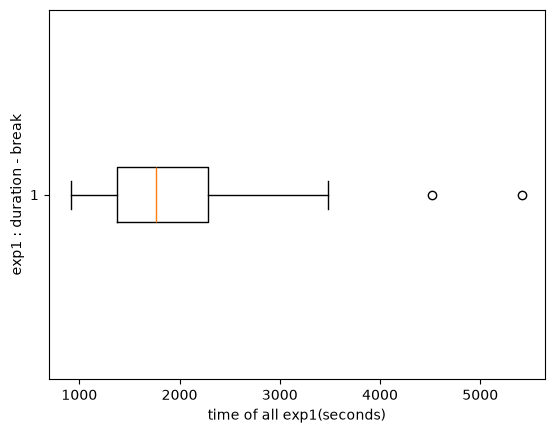

/tmp/ipykernel_538217/2250506076.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(time_of_all_exp2.dropna(), vert=False)


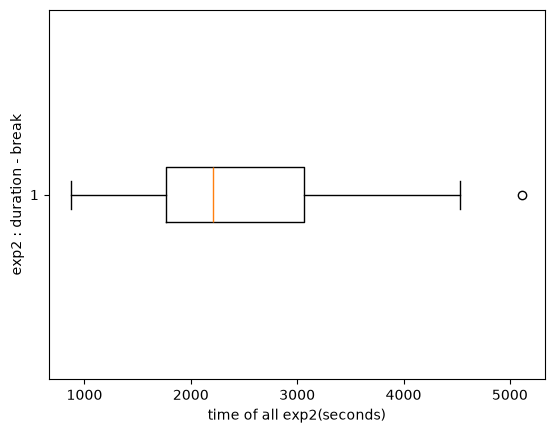

In [22]:
import matplotlib.pyplot as plt

plt.boxplot(time_of_all_exp1.dropna(), vert=False)
plt.xlabel("time of all exp1(seconds)")
plt.ylabel("exp1 : duration - break")
plt.show()


plt.boxplot(time_of_all_exp2.dropna(), vert=False)
plt.xlabel("time of all exp2(seconds)")
plt.ylabel("exp2 : duration - break")
plt.show()

In [23]:
#年齢
exp1_age = pd.to_numeric(
    exp1["D2_1"],
    errors="coerce"
)
print("exp1 age:")
print(exp1_age.describe())
print("NaN:", exp1_age.isna().sum())

exp2_age = pd.to_numeric(
    exp2["D2_1"],
    errors="coerce"
)
print("\nexp2 age:")
print(exp2_age.describe())
print("NaN:", exp2_age.isna().sum())

exp1 age:
count    88.000000
mean     45.840909
std      10.003317
min      22.000000
25%      38.000000
50%      44.500000
75%      52.000000
max      72.000000
Name: D2_1, dtype: float64
NaN: 0

exp2 age:
count    87.000000
mean     45.609195
std       7.610208
min      31.000000
25%      39.500000
50%      45.000000
75%      51.000000
max      64.000000
Name: D2_1, dtype: float64
NaN: 1


/tmp/ipykernel_538217/531027113.py:1: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(exp1_age.dropna(), vert=False)


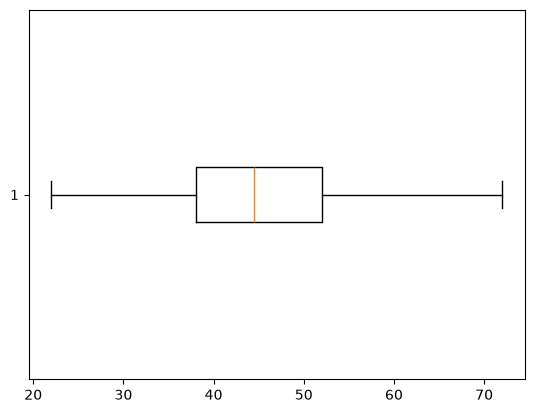

/tmp/ipykernel_538217/531027113.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(exp2_age.dropna(), vert=False)


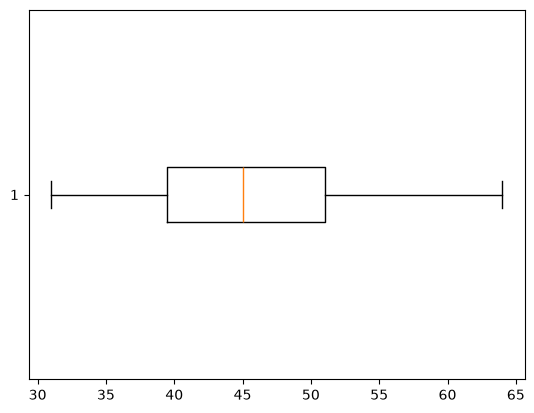

In [24]:
plt.boxplot(exp1_age.dropna(), vert=False)
plt.show()
plt.boxplot(exp2_age.dropna(), vert=False)
plt.show()

In [25]:
df["D2_1"].value_counts().get(72, 0)

np.int64(1)

In [26]:
df.loc[df["D2_1"] == 72, "IPAddress"]

160    14.193.27.208
Name: IPAddress, dtype: str

In [27]:
df.head()

,StartDate,EndDate,Status,IPAddress,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,RecipientLastName,...,5_Q1149_Page Submit,5_Q1149_Click Count,5_Q1150_1,5_Q1151_1,__js_DisplayedMessage,__js_MessageGroup,__js_MessageStatus,__js_MessageTimestamp,__js_MessageError,__js_MessageLogs
4,2026-08-22 09:31:58,2026-08-22 09:48:49,IP Address,126.72.104.33,100,1010,True,2026-08-22 09:48:50,R_9nvFNaU5rMNP8Vi,NaN,...,NaN,NaN,NaN,NaN,午後の作業に取りかかったよ,neutral,success,2026-08-22T00:48:30.677Z,NaN,"[{""displayedMessage"":""目を閉じてそのまま過ごしてたよ"",""messag..."
5,2026-08-22 09:35:38,2026-08-22 09:52:15,IP Address,219.104.142.133,100,995,True,2026-08-22 09:52:16,R_4l6l7Hlm3o0SkDf,NaN,...,NaN,NaN,NaN,NaN,明日の面接で質問にちゃんと答えられるか心配だ,negative,success,2026-08-22T00:51:48.610Z,NaN,"[{""displayedMessage"":""朝起きれない"",""messageGroup"":""..."
6,2026-08-22 09:33:32,2026-08-22 09:52:54,IP Address,123.225.222.135,100,1161,True,2026-08-22 09:52:55,R_4HKyBG3cpnZbBOp,NaN,...,NaN,NaN,NaN,NaN,今日は運動したし眠たいや,positive,success,2026-08-22T00:51:59.336Z,NaN,"[{""displayedMessage"":""今日から夏休みだね"",""messageGroup..."
8,2026-08-22 09:39:07,2026-08-22 09:53:53,IP Address,1.73.18.151,100,886,True,2026-08-22 09:53:53,R_9FDwQcYM0PlI2kN,NaN,...,2.866,5,59,68,一部だけ修正して反映しました,neutral,success,2026-08-22T00:53:38.572Z,NaN,"[{""displayedMessage"":""明かりを落として横になった"",""messageG..."
9,2026-08-22 09:34:57,2026-08-22 09:54:03,IP Address,121.92.154.87,100,1146,True,2026-08-22 09:54:04,R_41hDHe81EktidI7,NaN,...,NaN,NaN,NaN,NaN,外で変な音がした,negative,success,2026-08-22T00:53:18.126Z,NaN,"[{""displayedMessage"":""朝起きれない"",""messageGroup"":""..."


In [28]:
exp1_q = pd.concat([
    questions.to_frame().T,
    exp1
], ignore_index=True)

exp2_q = pd.concat([
    questions.to_frame().T,
    exp2
], ignore_index=True)

In [29]:
df.to_csv("../data/df_824.csv", index=False, encoding="utf-8-sig")
exp1.to_csv("../data/exp1_824.csv", index=False, encoding="utf-8-sig")
exp2.to_csv("../data/exp2_824.csv", index=False, encoding="utf-8-sig")
exp1_q.to_csv("../data/exp1_q_824.csv", index=False, encoding="utf-8-sig")
exp2_q.to_csv("../data/exp2_q_824.csv", index=False, encoding="utf-8-sig")